# 03 - Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
import os

In [2]:
sns.set_style('whitegrid')
df = pd.read_csv('../data/cleaned/cleaned_data.csv')
df.shape

(20640, 10)

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df['income_cat']= pd.cut(df['median_income'], bins= [0,1.5,3.0,4.5,6.0,np.inf], labels=[1,2,3,4,5])

Text(0.5, 1.0, 'Income Categories Distribution')

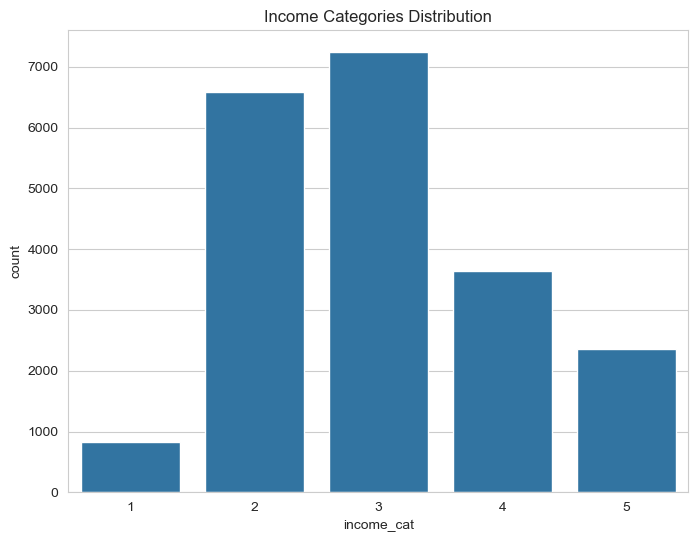

In [5]:
plt.figure(figsize=(8,6))
plt.tight_layout()
sns.barplot(df["income_cat"].value_counts().sort_index())
plt.title("Income Categories Distribution") 

### Creating test data that will be use for testing model after deployment
- spliting data by using StratifiedShuffleSplit
- Taking out 10% of data, for testing model after deployment

## Step 1: Deployment holdout

In [6]:
os.makedirs('../data/deployment_holdout', exist_ok=True)

df['income_cat'] = pd.cut(df['median_income'], bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1,2,3,4,5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
for train_index, test_index in split.split(df, df['income_cat']):
    train_data = df.loc[train_index].reset_index(drop=True)
    
    test_labels= df.loc[test_index]['median_house_value']
    test_data= df.loc[test_index].drop(columns=['median_house_value','income_cat'],axis=1)
    
test_labels.to_csv('../data/deployment_holdout/deployment_test_labels.csv',index=False)
test_data.to_csv('../data/deployment_holdout/deployment_test_data.csv',index=False)
    
print(f'train_data: {train_data.shape} | deployment test data: {test_data.shape} deployment labels: {test_labels.shape}')

train_data: (18576, 11) | deployment test data: (2064, 9) deployment labels: (2064,)


## Step 2: Train/test split (on the remaining train_data)

In [7]:
train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-118.26,34.06,33.0,1950.0,1047.0,3707.0,1012.0,1.7238,110000.0,<1H OCEAN,2
1,-120.72,38.38,9.0,1787.0,347.0,806.0,306.0,2.5250,157200.0,INLAND,2
2,-118.37,34.08,52.0,2946.0,695.0,1258.0,650.0,3.9783,374100.0,<1H OCEAN,3
3,-118.31,34.02,46.0,2217.0,489.0,1227.0,448.0,1.6851,108800.0,<1H OCEAN,2
4,-120.23,39.56,14.0,1781.0,346.0,734.0,287.0,2.4600,93000.0,INLAND,2


In [8]:
x = train_data.drop('median_house_value', axis=1)
y = train_data['median_house_value']

train_data.drop('income_cat',axis=1).to_csv('../data/training_data/train_data.csv',index=False)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10, random_state=42)
print(x_train.shape, x_test.shape)

(16718, 10) (1858, 10)


## Step 3: Work on a COPY for treated features

In [9]:
features = x_train.copy()
test_features = x_test.copy()

### Step 5: Handle missing values

In [10]:
m=features.isnull().sum()
m[m>0]

total_bedrooms    160
dtype: int64

In [11]:
features[features['total_bedrooms'].isnull()].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
1853,-118.45,34.30,27.0,2676.0,NaN,2661.0,623.0,4.3047,<1H OCEAN,3
11103,-118.27,34.17,52.0,2010.0,NaN,908.0,326.0,6.9135,<1H OCEAN,5
18351,-117.91,33.76,20.0,4413.0,NaN,4818.0,1063.0,2.8594,<1H OCEAN,2
15047,-118.55,34.19,18.0,5862.0,NaN,3161.0,1280.0,3.1106,<1H OCEAN,3
18052,-120.40,37.30,28.0,1401.0,NaN,967.0,257.0,1.5917,INLAND,2


In [12]:
from sklearn.impute import SimpleImputer

num_cols = features.select_dtypes(include='number').columns.tolist()

imputer = SimpleImputer(strategy='median')
features[num_cols] = imputer.fit_transform(features[num_cols])
test_features[num_cols] = imputer.transform(test_features[num_cols])

In [13]:
m=features.isnull().sum()
m[m>0]

Series([], dtype: int64)

## Step 6: Encode categorical variables

In [14]:
cat_cols = ['ocean_proximity']

In [15]:
features[cat_cols].value_counts()

ocean_proximity
<1H OCEAN          7333
INLAND             5360
NEAR OCEAN         2155
NEAR BAY           1867
ISLAND                3
Name: count, dtype: int64

In [16]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

In [17]:
encoded_train = pd.DataFrame(
    ohe.fit_transform(features[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=features.index)

encoded_test = pd.DataFrame(
    ohe.transform(test_features[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=test_features.index)

In [18]:
encoded_train.head()

,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
17845,0.0,0.0,0.0,1.0
586,0.0,0.0,0.0,0.0
15727,0.0,0.0,0.0,0.0
16740,1.0,0.0,0.0,0.0
17590,0.0,0.0,1.0,0.0


In [19]:
encoded_test.columns

Index(['ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [20]:
features = pd.concat([features.drop(columns=cat_cols), encoded_train], axis=1)
test_features = pd.concat([test_features.drop(columns=cat_cols), encoded_test], axis=1)

In [21]:
test_features.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,income_cat,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
9387,-117.25,33.92,7.0,9812.0,1914.0,5595.0,1729.0,4.1482,3,1.0,0.0,0.0,0.0
17236,-122.02,37.54,31.0,1240.0,264.0,719.0,236.0,3.5350,3,0.0,0.0,1.0,0.0
16429,-118.48,34.28,35.0,1511.0,274.0,873.0,254.0,5.5608,4,0.0,0.0,0.0,0.0
9864,-120.46,34.64,11.0,562.0,164.0,504.0,147.0,2.0161,2,0.0,0.0,0.0,1.0
7053,-119.75,34.44,28.0,1080.0,298.0,524.0,251.0,1.8432,2,0.0,0.0,0.0,1.0


In [22]:
def hist_box_plot(col,df):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        
    print(f"\n {col} | Skew: {df[col].skew():.2f} | Outliers: {outlier_count} ({outlier_count/len(df)*100:.1f}%)")
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
    sns.histplot(df[col], kde=True, ax=axes[0], color='steelblue')
    axes[0].axvline(df[col].mean(), color='red', linestyle='--', label=(f"Mean{df[col].mean():.2f}"))
    axes[0].axvline(df[col].median(), color='green', linestyle='--', label=(f"Median{df[col].median():.2f}"))
    axes[0].set_title(f'{col} - Distribution')
    axes[0].legend()
        
    sns.boxplot(x=df[col], ax=axes[1], color='skyblue')
    axes[1].set_title(f'{col} - Boxplot')
        
    plt.tight_layout()
    plt.show()


 housing_median_age | Skew: 0.06 | Outliers: 0 (0.0%)


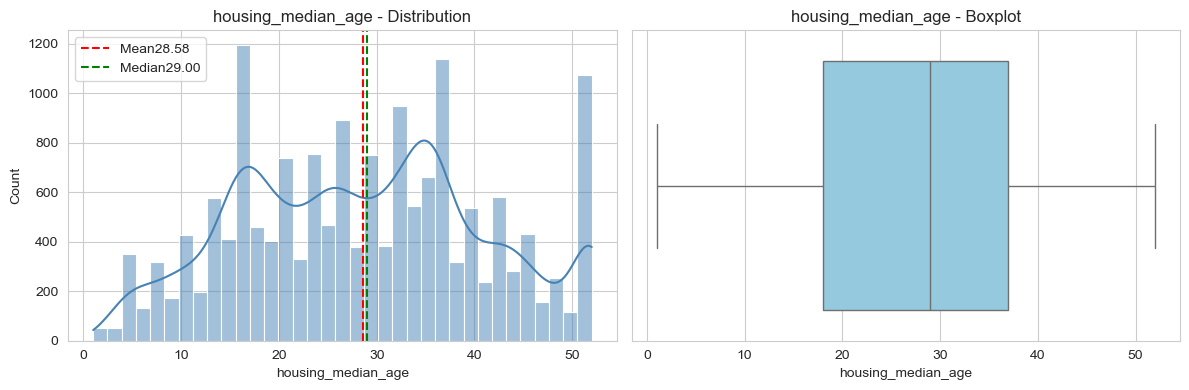

In [23]:
hist_box_plot('housing_median_age',features)

In [24]:
features['housing_median_age'].describe()

count    16718.000000
mean        28.584400
std         12.613242
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: housing_median_age, dtype: float64

### Observation: 
- housing_median_age is approximately symmetrical with a skewness of 0.06.
- No outliers are observed. However, the distribution has a noticeable spike at 52 years,indicating that the feature is capped at this value.
- Therefore, no need to handle skewness.


 total_rooms | Skew: 4.17 | Outliers: 1049 (6.3%)


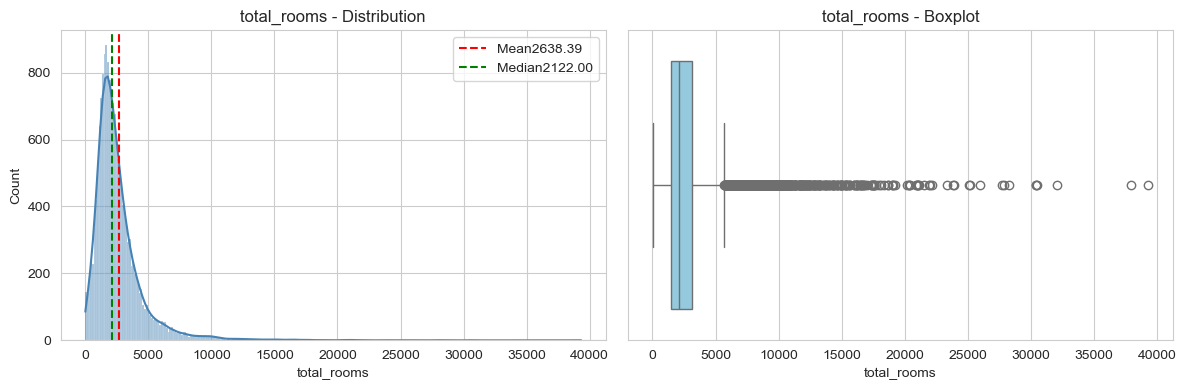

In [25]:
hist_box_plot('total_rooms',features)

In [26]:
features['total_rooms'].describe()

count    16718.000000
mean      2638.389102
std       2200.645295
min          6.000000
25%       1445.000000
50%       2122.000000
75%       3149.000000
max      39320.000000
Name: total_rooms, dtype: float64

In [27]:
features[features['total_rooms']>10000]['total_rooms'].count()

np.int64(243)

In [28]:
pct_99= features['total_rooms'].quantile(0.99)

In [29]:
print(pct_99)

11290.769999999964


In [30]:
features[features['total_rooms']> pct_99]['total_rooms'].count()

np.int64(168)

In [31]:
pt= PowerTransformer(method='yeo-johnson', standardize=False)

In [32]:
features[['total_rooms']] = pt.fit_transform(features[['total_rooms']])


 total_rooms | Skew: 0.12 | Outliers: 755 (4.5%)


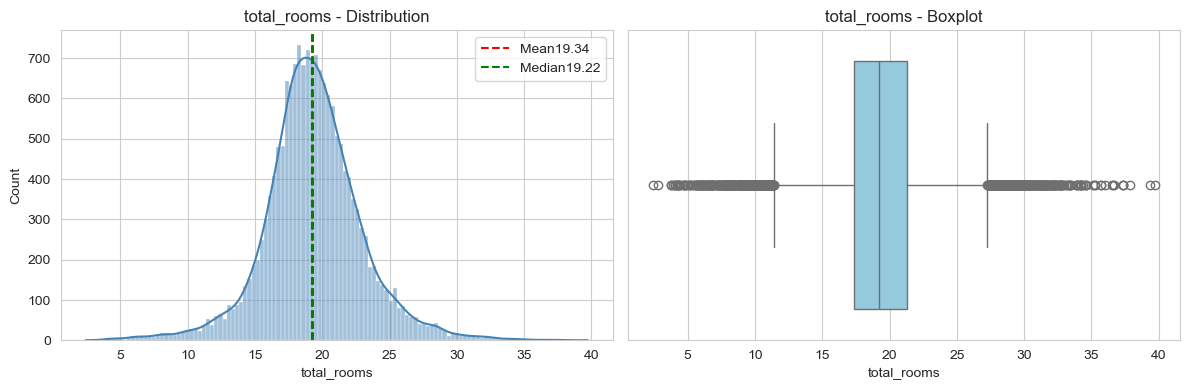

In [33]:
hist_box_plot('total_rooms',features)

In [34]:
test_features[['total_rooms']] = pt.transform(test_features[['total_rooms']])


 total_bedrooms | Skew: 3.40 | Outliers: 1067 (6.4%)


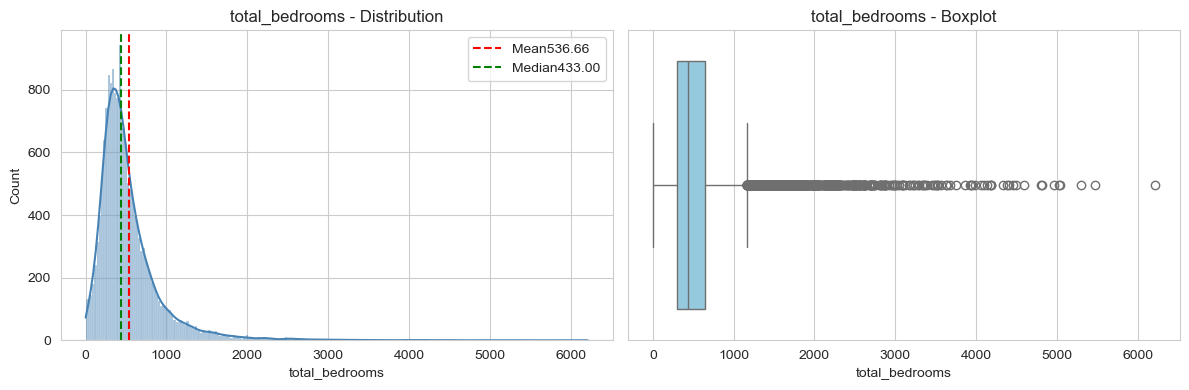

In [35]:
hist_box_plot('total_bedrooms',features)

In [36]:
features['total_bedrooms'].describe()

count    16718.000000
mean       536.662220
std        419.925473
min          1.000000
25%        296.000000
50%        433.000000
75%        642.750000
max       6210.000000
Name: total_bedrooms, dtype: float64

In [37]:
features[['total_bedrooms']] = pt.fit_transform(features[['total_bedrooms']])


 total_bedrooms | Skew: 0.10 | Outliers: 683 (4.1%)


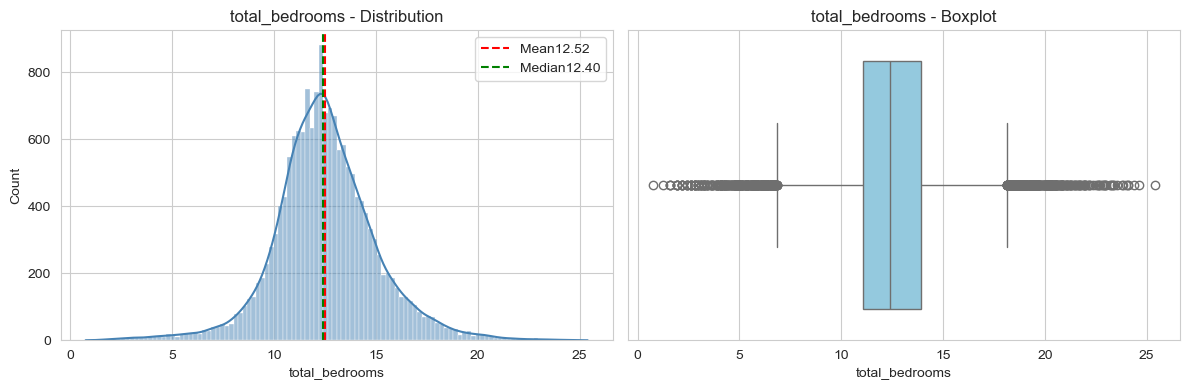

In [38]:
hist_box_plot('total_bedrooms',features)

In [39]:
test_features[['total_bedrooms']] = pt.transform(test_features[['total_bedrooms']])


 population | Skew: 4.75 | Outliers: 990 (5.9%)


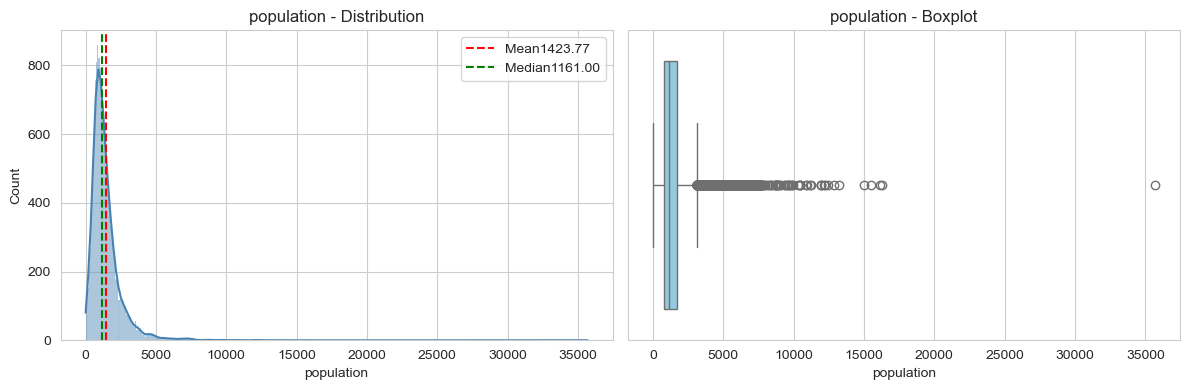

In [40]:
hist_box_plot('population',features)

In [41]:
features['population'].describe()

count    16718.000000
mean      1423.767317
std       1132.082322
min          3.000000
25%        785.000000
50%       1161.000000
75%       1719.000000
max      35682.000000
Name: population, dtype: float64

In [42]:
features['population'].quantile(0.99)

np.float64(5836.789999999975)

In [43]:
features[['population']] = pt.fit_transform(features[['population']])


 population | Skew: 0.11 | Outliers: 687 (4.1%)


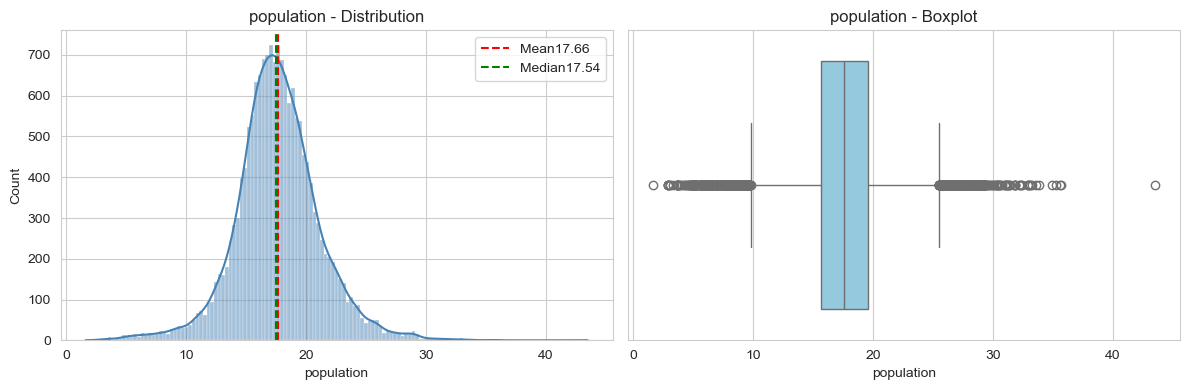

In [44]:
hist_box_plot('population',features)

In [45]:
test_features[['population']] = pt.transform(test_features[['population']])


 households | Skew: 3.34 | Outliers: 1004 (6.0%)


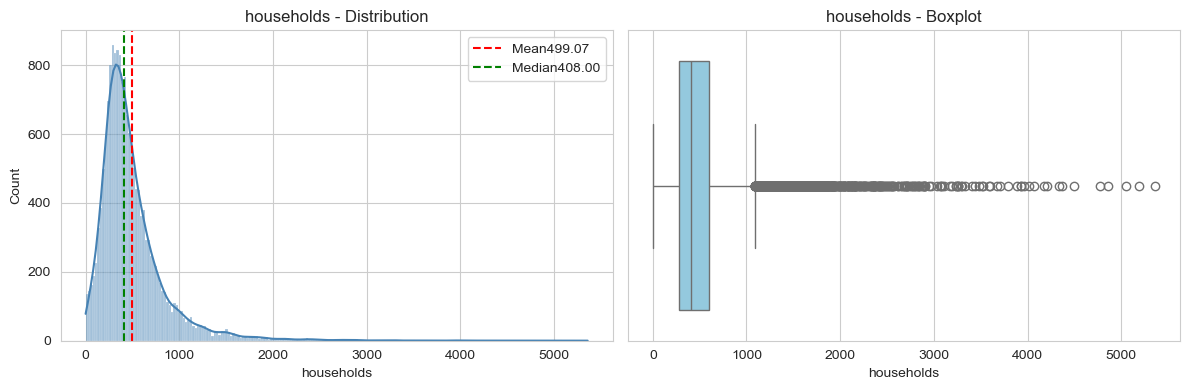

In [46]:
hist_box_plot('households',features)

In [47]:
features[['households']] = pt.fit_transform(features[['households']])


 households | Skew: 0.11 | Outliers: 708 (4.2%)


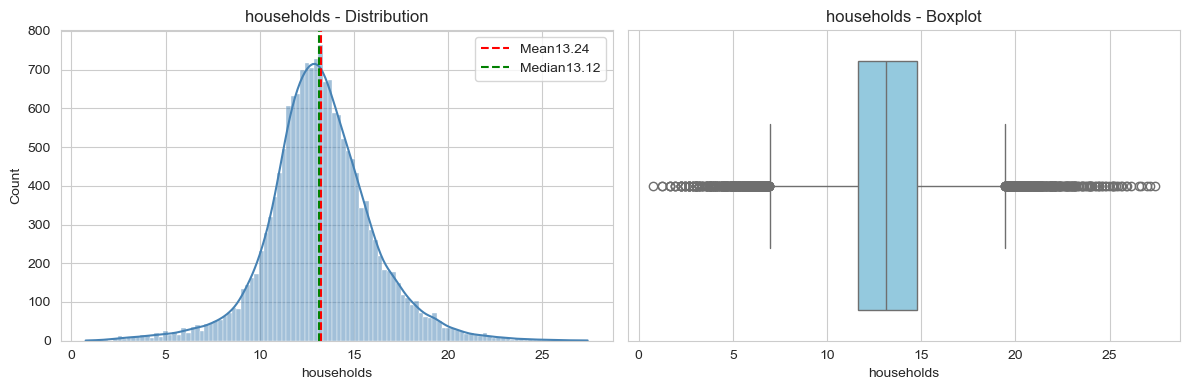

In [48]:
hist_box_plot('households',features)

In [49]:
test_features[['households']] = pt.transform(test_features[['households']])


 median_income | Skew: 1.63 | Outliers: 549 (3.3%)


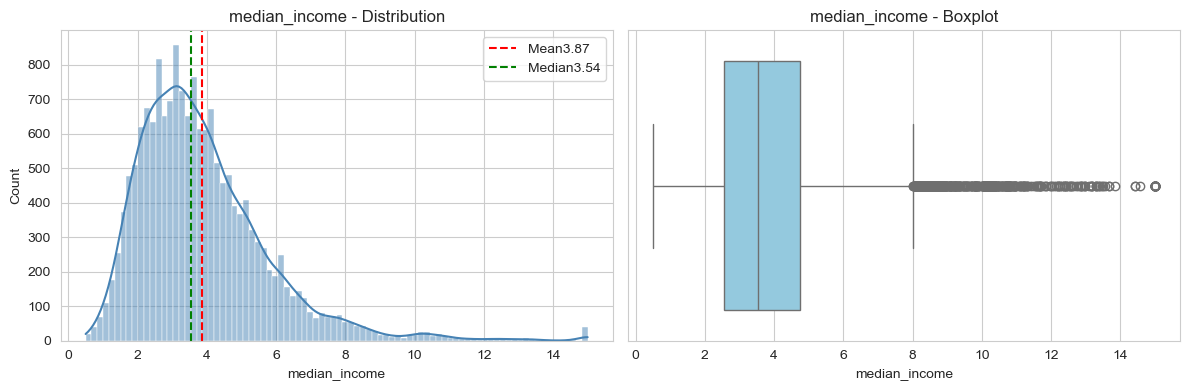

In [50]:
hist_box_plot('median_income',features)

In [51]:
features['median_income'].describe()

count    16718.000000
mean         3.873671
std          1.895947
min          0.499900
25%          2.567300
50%          3.538250
75%          4.746950
max         15.000100
Name: median_income, dtype: float64


 median_income | Skew: -0.00 | Outliers: 164 (1.0%)


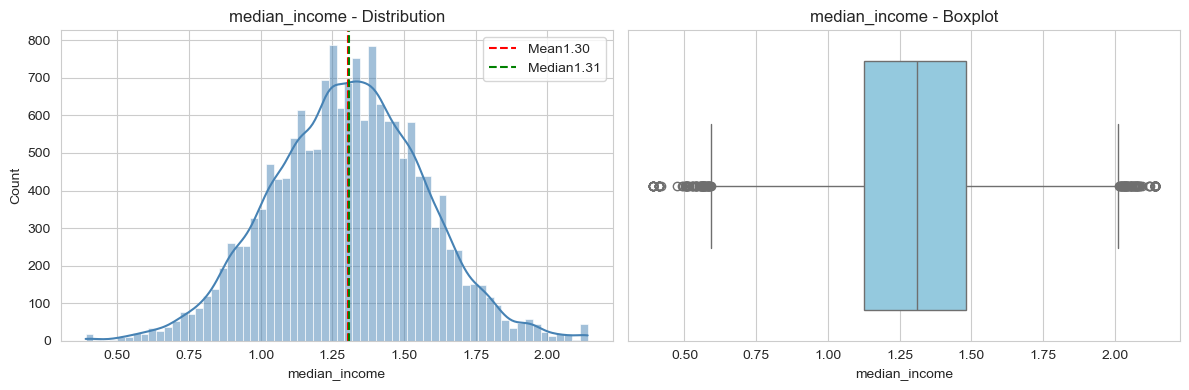

In [52]:
features[['median_income']] = pt.fit_transform(features[['median_income']])
hist_box_plot('median_income',features)

In [53]:
test_features[['median_income']] = pt.transform(test_features[['median_income']])

In [54]:
features.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,income_cat,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
17845,-117.10,32.58,27.0,20.300940,13.563659,20.113872,14.583038,1.084287,2,0.0,0.0,0.0,1.0
586,-117.66,33.62,16.0,24.192838,14.770730,22.230092,16.149297,1.632923,5,0.0,0.0,0.0,0.0
15727,-118.31,33.93,37.0,16.791963,10.440679,16.049089,11.236842,1.421966,3,0.0,0.0,0.0,0.0
16740,-121.04,37.60,27.0,15.504822,9.563078,14.335795,10.055963,1.037248,2,1.0,0.0,0.0,0.0
17590,-122.12,37.43,33.0,21.498885,14.044552,18.537925,14.944052,1.547532,4,0.0,0.0,1.0,0.0


In [55]:
test_features.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,income_cat,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
9387,-117.25,33.92,7.0,28.391730,18.739655,26.994619,20.071482,1.402064,3,1.0,0.0,0.0,0.0
17236,-122.02,37.54,31.0,16.640724,10.695347,15.274285,11.044954,1.308858,3,0.0,0.0,1.0,0.0
16429,-118.48,34.28,35.0,17.554056,10.817043,16.162734,11.308608,1.573954,4,0.0,0.0,0.0,0.0
9864,-120.46,34.64,11.0,13.345644,9.220378,13.746765,9.452398,0.992947,2,0.0,0.0,0.0,1.0
7053,-119.75,34.44,28.0,16.024782,11.095492,13.908073,11.265679,0.945098,2,0.0,0.0,0.0,1.0


In [56]:
features.drop('income_cat', axis=1,inplace=True)
test_features.drop('income_cat', axis=1,inplace=True)

In [57]:
features.to_csv('../data/processed/x_train_processed.csv',index=False)
y_train.to_csv('../data/processed/y_train.csv',index=False)

test_features.to_csv('../data/processed/x_test_processed.csv',index=False)
y_test.to_csv('../data/processed/y_test.csv',index=False)